# Random Forest Training Notebook

This notebook uses the same workflow as the training script.
The only difference is the model at the end.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

ROOT_DIR = Path.cwd().resolve().parent.parent
PYTHON_DIR = ROOT_DIR / "python"
if str(PYTHON_DIR) not in sys.path:
    sys.path.append(str(PYTHON_DIR))

from common import (  # noqa: E402
    CLASS_ORDER,
    coerce_feature_types,
    evaluate_predictions,
    load_tabular_file,
    build_preprocessor,
    split_feature_columns,
    infer_numeric_like_columns,
    standardize_columns,
    find_column,
    clean_rating_label,
    create_rating_group,
    IDENTIFIER_ALIASES,
    TARGET_ALIASES,
)

# Auto-detect the first CSV or Excel file in the data/ directory.
_data_dir = ROOT_DIR / "data"
_candidates = sorted(
    list(_data_dir.glob("*.csv")) + list(_data_dir.glob("*.xlsx")) + list(_data_dir.glob("*.xls"))
)
if not _candidates:
    raise FileNotFoundError(
        f"No CSV or Excel file found in {_data_dir}. ",
        "Please place your dataset there and re-run this cell.",
    )
DATA_PATH = _candidates[0]
print(f"Using dataset: {DATA_PATH}")
print("Imports ready")

Using dataset: C:\Users\winnie\OneDrive - Republic Polytechnic\Documents\FYP\CreditSight\data\set A corporate_rating.csv
Imports ready


In [3]:
# Step 1: Load the dataset.
raw_df = load_tabular_file(str(DATA_PATH))
df = standardize_columns(raw_df)
print(df.shape)
df.head()

(2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


In [4]:
# Step 2: Check missing values and duplicates.
missing_values = df.isna().sum().sort_values(ascending=False)
duplicate_rows = int(df.duplicated().sum())
print(missing_values[missing_values > 0])
print("Duplicate rows:", duplicate_rows)

Series([], dtype: int64)
Duplicate rows: 0


In [5]:
# Step 3: Create the RatingGroup target.
rating_column = find_column(df, TARGET_ALIASES)
if rating_column is None:
    raise ValueError("No rating column found in the dataset.")

working_df = df.copy()
working_df[rating_column] = working_df[rating_column].apply(clean_rating_label)
working_df["RatingGroup"] = working_df[rating_column].apply(create_rating_group)
working_df = working_df.dropna(subset=["RatingGroup"]).copy()

identifier_columns = []
for alias in IDENTIFIER_ALIASES:
    found = find_column(working_df, [alias])
    if found and found not in identifier_columns:
        identifier_columns.append(found)

if rating_column not in identifier_columns:
    identifier_columns.append(rating_column)

working_df = working_df.drop(columns=identifier_columns, errors="ignore")
working_df = infer_numeric_like_columns(working_df, exclude_columns=["RatingGroup"])
print(working_df["RatingGroup"].value_counts())

RatingGroup
Speculative        792
Investment-Low     671
Investment-High    494
Distressed          72
Name: count, dtype: int64


In [6]:
# Step 4: Select features and prepare the training data.
feature_columns = [column for column in working_df.columns if column != "RatingGroup"]
numeric_columns, categorical_columns = split_feature_columns(working_df, "RatingGroup", [])
X = working_df[feature_columns].copy()
X = coerce_feature_types(X, numeric_columns, categorical_columns)
y = working_df["RatingGroup"].copy()
print("Numeric columns:", numeric_columns)
print("Categorical columns:", categorical_columns)

Numeric columns: ['currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']
Categorical columns: ['Sector']


In [7]:
# Step 5: Split the dataset and train the model.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", RandomForestClassifier(random_state=42)),
    ]
)
pipeline.fit(X_train, y_train)
print("Model trained")

Model trained


In [8]:
# Step 6: Evaluate the trained model.
y_pred = pipeline.predict(X_test)
y_test_labels = label_encoder.inverse_transform(y_test)
y_pred_labels = label_encoder.inverse_transform(y_pred.astype(int))
metrics = evaluate_predictions(y_test_labels, y_pred_labels, CLASS_ORDER)
print(metrics["accuracy"])
print(metrics["classification_report_text"])


0.6830870279146142
                 precision    recall  f1-score   support

Investment-High       0.63      0.67      0.65       148
 Investment-Low       0.67      0.58      0.62       201
    Speculative       0.72      0.84      0.77       238
     Distressed       1.00      0.09      0.17        22

       accuracy                           0.68       609
      macro avg       0.75      0.54      0.55       609
   weighted avg       0.69      0.68      0.67       609



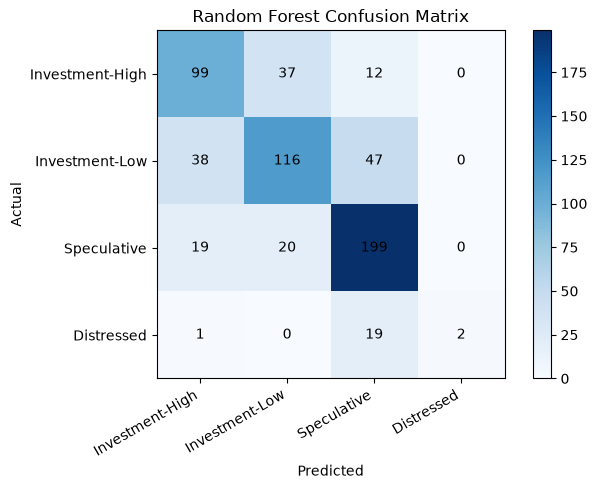

In [9]:
# Step 7: Show the confusion matrix.
cm = np.array(metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black",
        )

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## Z-Score Standardization

Z-Score standardization transforms each numerical feature using its mean and standard deviation. The StandardScaler is fitted using `X_train` only, then the same fitted scaler is applied to `X_test` to prevent data leakage.

Baseline vs Z-Score metrics:
               Scenario  Accuracy  Weighted F1  Macro F1
               Baseline  0.683087     0.670542  0.552246
Z-Score Standardization  0.697865     0.686084  0.564095

Z-Score classification report:
                 precision    recall  f1-score   support

Investment-High       0.68      0.67      0.67       148
 Investment-Low       0.69      0.62      0.65       201
    Speculative       0.72      0.84      0.77       238
     Distressed       0.67      0.09      0.16        22

       accuracy                           0.70       609
      macro avg       0.69      0.55      0.56       609
   weighted avg       0.70      0.70      0.69       609



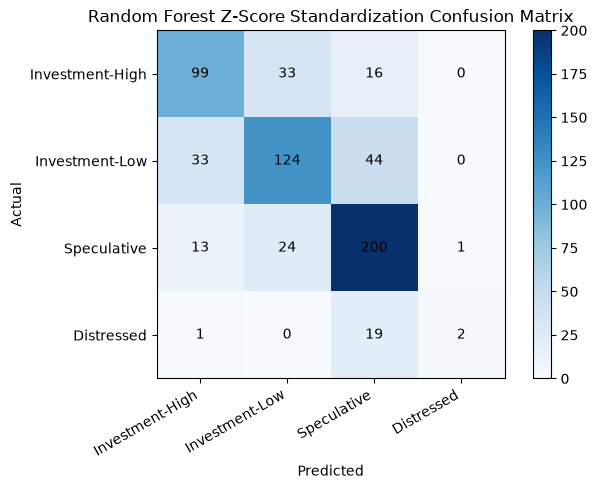

In [10]:
# Z-Score Standardization Experiment

baseline_metrics = dict(metrics)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

try:
    one_hot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

# Numerical preprocessing:
# 1. Replace missing values using the median
# 2. Apply Z-Score standardization
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Categorical preprocessing:
# 1. Replace missing values
# 2. Apply one-hot encoding
categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot),
    ]
)

# Combine the numerical and categorical preprocessing
zscore_preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipe, numeric_columns),
        ("categorical", categorical_pipe, categorical_columns),
    ],
    remainder="drop",
)

# Build the Random Forest pipeline
zscore_pipeline = Pipeline(
    steps=[
        ("preprocessor", zscore_preprocessor),
        ("model", RandomForestClassifier(random_state=42)),
    ]
)

# Fit using the existing training split only
zscore_pipeline.fit(X_train, y_train)

# Predict using the unchanged test set
zscore_pred = zscore_pipeline.predict(X_test)

zscore_pred_labels = label_encoder.inverse_transform(
    zscore_pred.astype(int)
)

zscore_metrics = evaluate_predictions(
    y_test_labels,
    zscore_pred_labels,
    CLASS_ORDER
)

# Compare baseline and Z-Score results
comparison_table = pd.DataFrame(
    [
        {
            "Scenario": "Baseline",
            "Accuracy": baseline_metrics["accuracy"],
            "Weighted F1": baseline_metrics["weighted_f1"],
            "Macro F1": baseline_metrics["macro_f1"],
        },
        {
            "Scenario": "Z-Score Standardization",
            "Accuracy": zscore_metrics["accuracy"],
            "Weighted F1": zscore_metrics["weighted_f1"],
            "Macro F1": zscore_metrics["macro_f1"],
        },
    ]
)

print("Baseline vs Z-Score metrics:")
print(comparison_table.to_string(index=False))

print()
print("Z-Score classification report:")
print(zscore_metrics["classification_report_text"])

# Confusion matrix
cm = np.array(zscore_metrics["confusion_matrix"])

fig, ax = plt.subplots(figsize=(7, 5))
image = ax.imshow(cm, cmap="Blues")

ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))

ax.set_xticklabels(
    CLASS_ORDER,
    rotation=30,
    ha="right"
)

ax.set_yticklabels(CLASS_ORDER)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Z-Score Standardization Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black"
        )

fig.colorbar(image, ax=ax)
plt.tight_layout()
plt.show()

## Experiment 7: Hyperparameter Tuning

This experiment uses the final selected preprocessing flow, fits `GridSearchCV` only on `X_train`, and evaluates the best estimator on the untouched `X_test`.


Best parameters:
{'model__bootstrap': False, 'model__class_weight': None, 'model__criterion': 'gini', 'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 100}

Best cross-validation accuracy: 0.642254

Untuned vs tuned metrics:
Scenario  Accuracy  Weighted F1  Macro F1
 Untuned  0.683087     0.670542  0.552246
   Tuned  0.712644     0.701542  0.576142

Tuned classification report:
                 precision    recall  f1-score   support

Investment-High       0.71      0.69      0.70       148
 Investment-Low       0.71      0.64      0.67       201
    Speculative       0.72      0.84      0.78       238
     Distressed       0.50      0.09      0.15        22

       accuracy                           0.71       609
      macro avg       0.66      0.57      0.58       609
   weighted avg       0.71      0.71      0.70       609



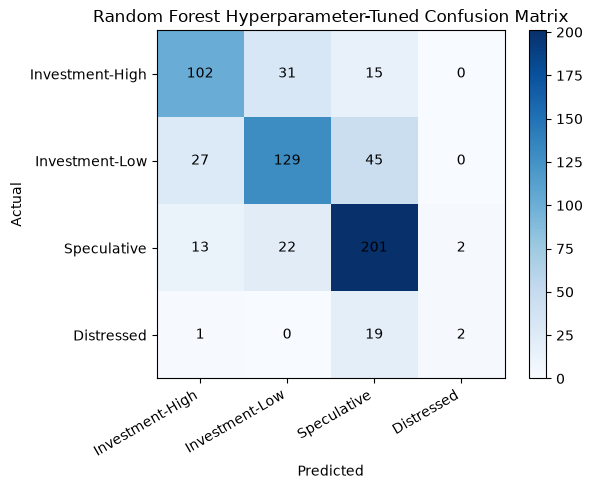

Conclusion: Keep - tuning improved or matched the untuned test performance.


In [11]:
# Experiment 7: Hyperparameter Tuning
from sklearn.base import clone
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline

final_preprocessor = build_preprocessor(numeric_columns, categorical_columns)
base_model = clone(pipeline.named_steps["model"])

untuned_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", clone(base_model)),
    ]
)
untuned_pipeline.fit(X_train, y_train)
untuned_pred = untuned_pipeline.predict(X_test)
untuned_pred_labels = label_encoder.inverse_transform(untuned_pred.astype(int))
untuned_metrics = evaluate_predictions(y_test_labels, untuned_pred_labels, CLASS_ORDER)

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            ("preprocessor", build_preprocessor(numeric_columns, categorical_columns)),
            ("model", clone(base_model)),
        ]
    ),
    param_grid={
    "model__class_weight": [None, "balanced"],
    "model__criterion": ["gini", "entropy"],
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_leaf": [1, 2, 4],
    "model__min_samples_split": [2, 5, 10],
    "model__bootstrap": [True, False],
},
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)
search.fit(X_train, y_train)

best_pipeline = search.best_estimator_
best_pred = best_pipeline.predict(X_test)
best_pred_labels = label_encoder.inverse_transform(best_pred.astype(int))
tuned_metrics = evaluate_predictions(y_test_labels, best_pred_labels, CLASS_ORDER)

print("Best parameters:")
print(search.best_params_)
print()
print(f"Best cross-validation accuracy: {search.best_score_:.6f}")
print()

comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned",
            "Accuracy": untuned_metrics["accuracy"],
            "Weighted F1": untuned_metrics["weighted_f1"],
            "Macro F1": untuned_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned",
            "Accuracy": tuned_metrics["accuracy"],
            "Weighted F1": tuned_metrics["weighted_f1"],
            "Macro F1": tuned_metrics["macro_f1"],
        },
    ]
)
print("Untuned vs tuned metrics:")
print(comparison.to_string(index=False))
print()
print("Tuned classification report:")
print(tuned_metrics["classification_report_text"])

cm = np.array(tuned_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASS_ORDER)))
ax.set_yticks(range(len(CLASS_ORDER)))
ax.set_xticklabels(CLASS_ORDER, rotation=30, ha="right")
ax.set_yticklabels(CLASS_ORDER)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title("Random Forest Hyperparameter-Tuned Confusion Matrix")

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(column_index, row_index, cm[row_index, column_index], ha="center", va="center", color="black")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

if tuned_metrics["accuracy"] > untuned_metrics["accuracy"] or (
    tuned_metrics["accuracy"] == untuned_metrics["accuracy"]
    and tuned_metrics["weighted_f1"] >= untuned_metrics["weighted_f1"]
):
    conclusion = "Keep"
    reason = "tuning improved or matched the untuned test performance."
else:
    conclusion = "Reject"
    reason = "tuning did not improve the untuned test performance."

print(f"Conclusion: {conclusion} - {reason}")


In [12]:
# Preserve the hyperparameter-tuned Random Forest without normalization.
# Run this immediately after the hyperparameter-only tuning experiment.

import copy

rf_hyper_only_pipeline = copy.deepcopy(best_pipeline)

print("Hyperparameter-only Random Forest pipeline preserved.")
print(rf_hyper_only_pipeline)

Hyperparameter-only Random Forest pipeline preserved.
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['currentRatio', 'quickRatio',
                                                   'cashRatio',
                                                   'daysOfSalesOutstanding',
                                                   'netProfitMargin',
                                                   'pretaxProfitMargin',
                                                   'grossProfitMargin',
                                                   'operatingProfitMargin',
                                                   'returnOnAssets',
                                                   'returnOnCapitalEmployed',
          

## Experiment 8: Z-Score Standardization + Hyperparameter Tuning

This experiment applies Z-Score standardization to the numerical features and then performs Random Forest hyperparameter tuning using GridSearchCV. The StandardScaler and Random Forest model are fitted inside each cross-validation fold using the training data only. The test data remains untouched until the final evaluation.

Best parameters:
model__max_depth: 20
model__max_features: log2
model__min_samples_leaf: 1
model__min_samples_split: 2
model__n_estimators: 200

Best cross-validation accuracy: 0.631690

Untuned vs tuned Z-Score metrics:
       Scenario  Accuracy  Weighted F1  Macro F1
Untuned Z-Score  0.697865     0.686084  0.564095
  Tuned Z-Score  0.689655     0.677524  0.558619

Tuned Z-Score classification report:
                 precision    recall  f1-score   support

Investment-High       0.69      0.69      0.69       148
 Investment-Low       0.64      0.58      0.61       201
    Speculative       0.72      0.84      0.77       238
     Distressed       0.67      0.09      0.16        22

       accuracy                           0.69       609
      macro avg       0.68      0.55      0.56       609
   weighted avg       0.69      0.69      0.68       609



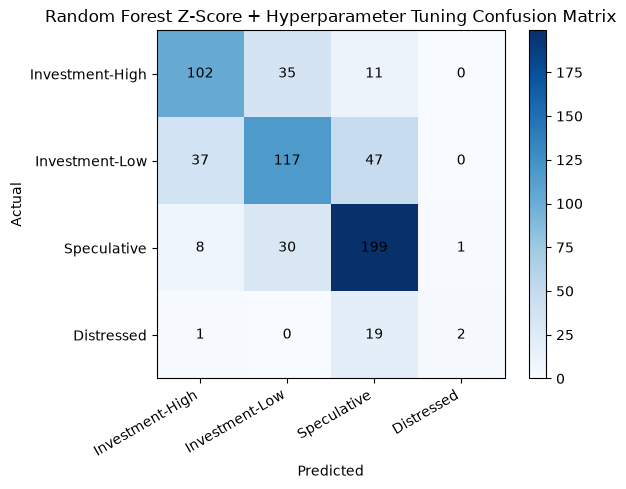

Conclusion: Reject - hyperparameter tuning did not improve the untuned Z-Score model.


In [13]:
# Experiment 8: Z-Score Standardization + Hyperparameter Tuning

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Create a new Z-Score preprocessor each time
def make_zscore_preprocessor():

    try:
        one_hot = OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    except TypeError:
        one_hot = OneHotEncoder(
            handle_unknown="ignore",
            sparse=False
        )

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(strategy="most_frequent")
            ),
            ("onehot", one_hot),
        ]
    )

    return ColumnTransformer(
        transformers=[
            (
                "num",
                numeric_pipeline,
                numeric_columns
            ),
            (
                "cat",
                categorical_pipeline,
                categorical_columns
            ),
        ],
        remainder="drop"
    )


# Copy the original Random Forest model
base_model = clone(
    pipeline.named_steps["model"]
)


# ------------------------------------------------------------
# Untuned Z-Score pipeline
# ------------------------------------------------------------

untuned_zscore_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            make_zscore_preprocessor()
        ),
        (
            "model",
            clone(base_model)
        ),
    ]
)

untuned_zscore_pipeline.fit(
    X_train,
    y_train
)

untuned_zscore_pred = untuned_zscore_pipeline.predict(
    X_test
)

untuned_zscore_pred_labels = label_encoder.inverse_transform(
    untuned_zscore_pred.astype(int)
)

untuned_zscore_metrics = evaluate_predictions(
    y_test_labels,
    untuned_zscore_pred_labels,
    CLASS_ORDER
)


# ------------------------------------------------------------
# Hyperparameter tuning with Z-Score
# ------------------------------------------------------------

search = GridSearchCV(
    estimator=Pipeline(
        steps=[
            (
                "preprocessor",
                make_zscore_preprocessor()
            ),
            (
                "model",
                clone(base_model)
            ),
        ]
    ),

    # Your original Random Forest grid
    param_grid={
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2"],
    },

    cv=StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    ),

    scoring="accuracy",
    n_jobs=-1,
    refit=True,
)

search.fit(
    X_train,
    y_train
)


# Use the best Z-Score pipeline
best_pipeline = search.best_estimator_

best_pred = best_pipeline.predict(
    X_test
)

best_pred_labels = label_encoder.inverse_transform(
    best_pred.astype(int)
)

tuned_zscore_metrics = evaluate_predictions(
    y_test_labels,
    best_pred_labels,
    CLASS_ORDER
)


# ------------------------------------------------------------
# Display the tuning results
# ------------------------------------------------------------

print("Best parameters:")

for parameter, value in search.best_params_.items():
    print(f"{parameter}: {value}")

print()
print(
    f"Best cross-validation accuracy: "
    f"{search.best_score_:.6f}"
)
print()


# Compare untuned and tuned Z-Score results
comparison = pd.DataFrame(
    [
        {
            "Scenario": "Untuned Z-Score",
            "Accuracy": untuned_zscore_metrics["accuracy"],
            "Weighted F1": untuned_zscore_metrics["weighted_f1"],
            "Macro F1": untuned_zscore_metrics["macro_f1"],
        },
        {
            "Scenario": "Tuned Z-Score",
            "Accuracy": tuned_zscore_metrics["accuracy"],
            "Weighted F1": tuned_zscore_metrics["weighted_f1"],
            "Macro F1": tuned_zscore_metrics["macro_f1"],
        },
    ]
)

print("Untuned vs tuned Z-Score metrics:")
print(comparison.to_string(index=False))

print()
print("Tuned Z-Score classification report:")
print(
    tuned_zscore_metrics[
        "classification_report_text"
    ]
)


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

cm = np.array(
    tuned_zscore_metrics["confusion_matrix"]
)

fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(
    cm,
    cmap="Blues"
)

ax.set_xticks(
    range(len(CLASS_ORDER))
)

ax.set_yticks(
    range(len(CLASS_ORDER))
)

ax.set_xticklabels(
    CLASS_ORDER,
    rotation=30,
    ha="right"
)

ax.set_yticklabels(
    CLASS_ORDER
)

ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

ax.set_title(
    "Random Forest Z-Score + Hyperparameter Tuning "
    "Confusion Matrix"
)

for row_index in range(cm.shape[0]):
    for column_index in range(cm.shape[1]):
        ax.text(
            column_index,
            row_index,
            cm[row_index, column_index],
            ha="center",
            va="center",
            color="black"
        )

fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

if (
    tuned_zscore_metrics["accuracy"]
    >
    untuned_zscore_metrics["accuracy"]
):

    conclusion = "Keep"

    reason = (
        "hyperparameter tuning improved the "
        "Z-Score test accuracy."
    )

elif (
    tuned_zscore_metrics["accuracy"]
    ==
    untuned_zscore_metrics["accuracy"]
    and
    tuned_zscore_metrics["weighted_f1"]
    >
    untuned_zscore_metrics["weighted_f1"]
):

    conclusion = "Keep"

    reason = (
        "the accuracy remained unchanged, but the "
        "weighted F1-score improved."
    )

else:

    conclusion = "Reject"

    reason = (
        "hyperparameter tuning did not improve the "
        "untuned Z-Score model."
    )

print(
    f"Conclusion: {conclusion} - {reason}"
)

## Explainable AI: SHAP Feature Importance

This section explains the final Random Forest model trained using Z-Score standardization and hyperparameter tuning.

Confirmed: SHAP is using the hyperparameter-only Random Forest.
Confirmed: No Z-Score, Min-Max or other normalization is included.

Final model used for SHAP:
RandomForestClassifier(bootstrap=False, max_depth=20, min_samples_split=5,
                       random_state=42)

Top SHAP features:


,Feature,Mean Absolute SHAP Value,Rank
0,operatingCashFlowPerShare,0.041575,1
1,returnOnAssets,0.023454,2
2,netProfitMargin,0.017492,3
3,returnOnCapitalEmployed,0.017475,4
4,operatingCashFlowSalesRatio,0.015289,5
5,pretaxProfitMargin,0.014612,6
6,ebitPerRevenue,0.012680,7
7,returnOnEquity,0.011988,8
8,grossProfitMargin,0.011204,9
9,freeCashFlowPerShare,0.010111,10


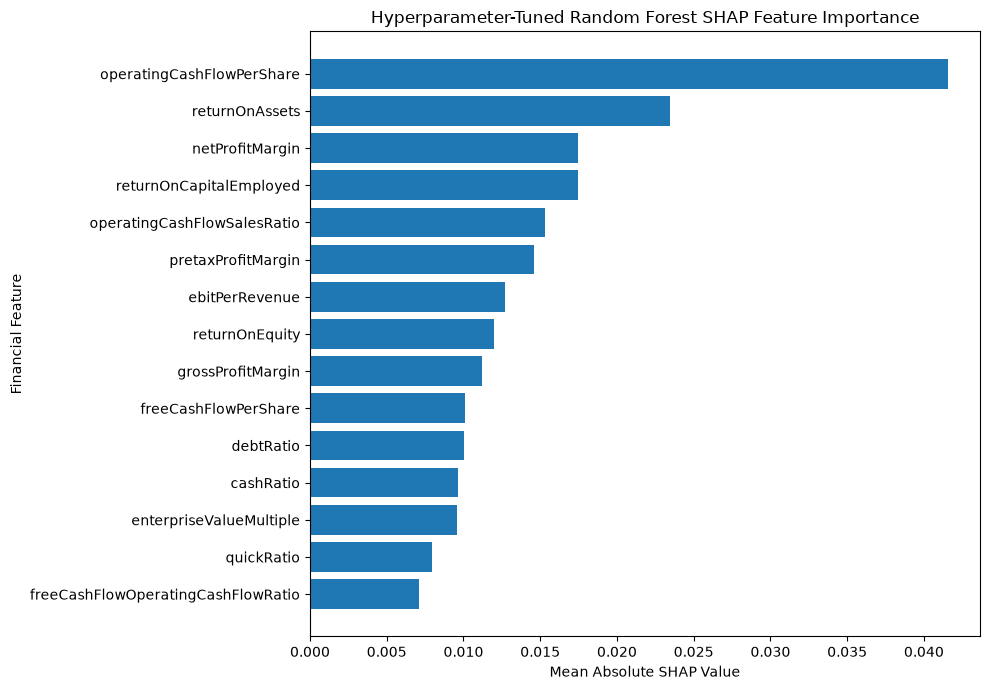

In [15]:
# Final Random Forest SHAP Feature Importance
# Explains only the hyperparameter-tuned Random Forest without normalization.

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Check that the hyperparameter-only model was preserved earlier.
if "rf_hyper_only_pipeline" not in globals():
    raise NameError(
        "rf_hyper_only_pipeline was not found. "
        "Run the preservation cell immediately after the "
        "hyperparameter-only tuning experiment."
    )

# Use the preserved hyperparameter-only pipeline.
# Do not use best_pipeline because later experiments may overwrite it.
final_pipeline = rf_hyper_only_pipeline

# Check that no normalization is included.
pipeline_text = repr(final_pipeline)

normalization_methods = [
    "StandardScaler",
    "MinMaxScaler",
    "MaxAbsScaler",
    "RobustScaler",
    "Normalizer"
]

detected_normalization = [
    method
    for method in normalization_methods
    if method in pipeline_text
]

if detected_normalization:
    raise ValueError(
        "The selected pipeline contains normalization: "
        + ", ".join(detected_normalization)
    )

print("Confirmed: SHAP is using the hyperparameter-only Random Forest.")
print("Confirmed: No Z-Score, Min-Max or other normalization is included.")

# Extract the fitted preprocessor and Random Forest model.
final_preprocessor = final_pipeline.named_steps["preprocessor"]
final_model = final_pipeline.named_steps["model"]

# Confirm the correct model is being used.
if final_model.__class__.__name__ != "RandomForestClassifier":
    raise TypeError(
        "Expected RandomForestClassifier, but detected: "
        f"{final_model.__class__.__name__}"
    )

# Apply the fitted preprocessing steps.
X_train_transformed = final_preprocessor.transform(X_train)
X_test_transformed = final_preprocessor.transform(X_test)

# Convert sparse matrices to normal NumPy arrays.
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

X_train_transformed = np.asarray(X_train_transformed)
X_test_transformed = np.asarray(X_test_transformed)

# Retrieve transformed feature names.
feature_names = np.asarray(
    final_preprocessor.get_feature_names_out(),
    dtype=str
)

# Remove prefixes such as num__ and cat__.
display_feature_names = np.asarray(
    [
        feature_name.split("__", 1)[-1]
        for feature_name in feature_names
    ]
)

# Confirm the number of names matches the transformed data.
if X_test_transformed.shape[1] != len(feature_names):
    raise ValueError(
        "The transformed feature count does not match "
        "the number of feature names."
    )

# Use a fixed sample of test records to reduce processing time.
explanation_size = min(100, X_test_transformed.shape[0])

random_generator = np.random.default_rng(42)

selected_indices = random_generator.choice(
    X_test_transformed.shape[0],
    size=explanation_size,
    replace=False
)

explanation_data = X_test_transformed[selected_indices]

# Create the SHAP TreeExplainer.
shap_explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values.
shap_result = shap_explainer(explanation_data)

# Support different SHAP output formats.
if isinstance(shap_result, list):
    shap_array = np.stack(
        [
            np.asarray(class_values)
            for class_values in shap_result
        ],
        axis=-1
    )

elif hasattr(shap_result, "values"):
    shap_array = np.asarray(shap_result.values)

else:
    shap_array = np.asarray(shap_result)

# Calculate mean absolute SHAP values.
if shap_array.ndim == 2:
    # Format: observations, features
    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=0
    )

elif shap_array.ndim == 3:
    # Identify which axis represents the features.
    possible_feature_axes = [
        axis_number
        for axis_number, axis_size in enumerate(shap_array.shape)
        if axis_size == len(feature_names)
    ]

    if not possible_feature_axes:
        raise ValueError(
            "Could not identify the feature axis. "
            f"SHAP shape: {shap_array.shape}"
        )

    feature_axis = possible_feature_axes[0]

    axes_to_average = tuple(
        axis_number
        for axis_number in range(shap_array.ndim)
        if axis_number != feature_axis
    )

    mean_abs_shap = np.mean(
        np.abs(shap_array),
        axis=axes_to_average
    )

else:
    raise ValueError(
        f"Unsupported SHAP dimensions: {shap_array.ndim}"
    )

mean_abs_shap = np.asarray(mean_abs_shap).reshape(-1)

# Confirm SHAP values match the feature names.
if len(mean_abs_shap) != len(display_feature_names):
    raise ValueError(
        "The number of SHAP values does not match "
        "the number of feature names."
    )

# Create the ranked feature-importance table.
shap_importance = pd.DataFrame(
    {
        "Feature": display_feature_names,
        "Mean Absolute SHAP Value": mean_abs_shap
    }
)

# Sort from highest to lowest importance.
shap_importance = shap_importance.sort_values(
    "Mean Absolute SHAP Value",
    ascending=False
).reset_index(drop=True)

# Add Rank as the last column.
shap_importance["Rank"] = shap_importance.index + 1

# Round values to 6 decimal places.
shap_importance["Mean Absolute SHAP Value"] = (
    shap_importance["Mean Absolute SHAP Value"].round(6)
)

# Arrange columns like the second picture.
shap_importance = shap_importance[
    [
        "Feature",
        "Mean Absolute SHAP Value",
        "Rank"
    ]
]

# Display the model information.
print("\nFinal model used for SHAP:")
print(final_model)

print("\nTop SHAP features:")
display(shap_importance.head(15))

# Prepare the top 15 features for the chart.
top_features = shap_importance.head(15).sort_values(
    "Mean Absolute SHAP Value",
    ascending=True
)

# Plot the top 15 SHAP feature importance values.
plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Mean Absolute SHAP Value"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Financial Feature")
plt.title(
    "Hyperparameter-Tuned Random Forest "
    "SHAP Feature Importance"
)

plt.tight_layout()
plt.show()